<a href="https://colab.research.google.com/github/xujiahengbill-bot/Harris/blob/main/sleep_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pregress

In [ ]:
import pregress as pr
import pandas as pd
df = pd.read_csv('Sleephealth.csv')

In [ ]:
top_5_occupations = df['Occupation'].value_counts().nlargest(5)
top_occupations_df = df[df['Occupation'].isin(top_5_occupations.index)]

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


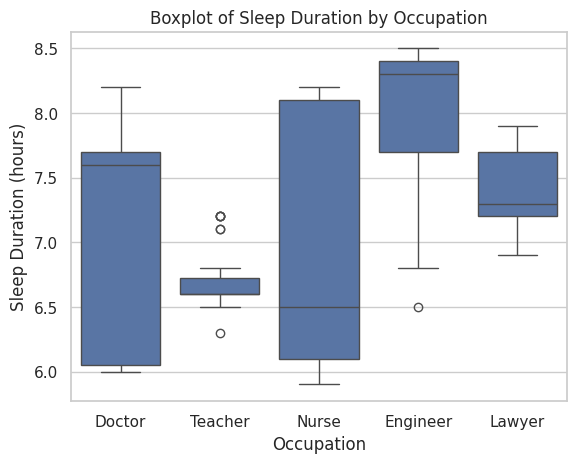

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_occupations_df = df[df['Occupation'].isin(top_5_occupations.index)]

sns.set_theme(style='whitegrid')

ax = sns.boxplot(x='Occupation', y='SleepDuration', data=top_occupations_df)

plt.xlabel("Occupation")
plt.ylabel("Sleep Duration (hours)")
plt.title("Boxplot of Sleep Duration by Occupation")

plt.show()


Teachers tend to sleep less compared to other occupations, with a more consistent but lower sleep duration.

Nurses and Engineers tend to have the highest and most variable sleep durations, suggesting that their sleep patterns might be less predictable.

The presence of outliers for Teachers and Nurses suggests that some individuals in these occupations experience significantly shorter sleep durations than their peers.

In [ ]:
SW = pr.step("SleepDuration~QualityofSleep+HeartRate+DailySteps",data = top_occupations_df, method = "SW")
pr.summary(SW)

Initial aic: 723.7481260462364
Best aic: 274.24142937157944
Best aic: 267.9238958387191
Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                  coef  std err       t     P>|t|     
Intercept       0.8839    0.587   1.505  0.133000     
QualityofSleep  0.6736    0.024  28.321  0.000000  ***
HeartRate       0.0192    0.007   2.890  0.004000   **

Model Statistics:
------------------------------------------------------
R-squared: 0.7907                AIC: 267.9239
Adj. R-squared: 0.7893           BIC: 278.9746
F-statistic: 549.70 on 2 and 291 DF, p-value: 0.000000


R-squared: The model's R-squared value is 0.7907, meaning that approximately 79.07% of the variance in sleep duration is explained by the model. This is a relatively high R-squared value, suggesting a good fit.
AIC (Akaike Information Criterion): 267.9239, a lower value indicates a better fit.
BIC (Bayesian Information Criterion): 278.9746, also used for model comparison, and a lower BIC indicates a better model.

# ANOVA Test

In [ ]:
top_occupations_df.BMI.value_counts()

,count
BMI,
Normal,169
Overweight,104
Normal Weight,14
Obese,7


In [ ]:
top_occupations_df.groupby('BMI',observed = False)['Stress'].mean()

,Stress
BMI,
Normal,5.301775
Normal Weight,5.357143
Obese,4.714286
Overweight,5.221154


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


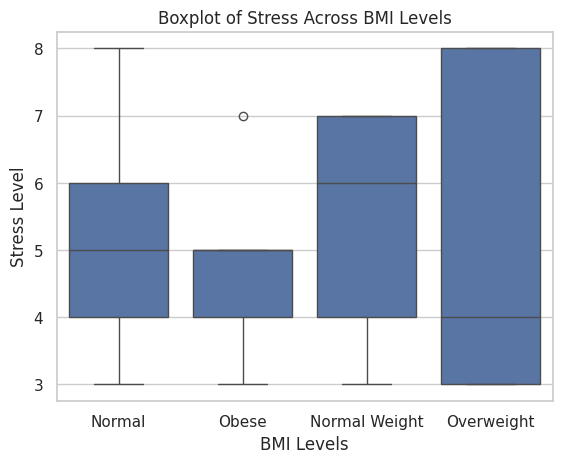

In [ ]:
sns.boxplot(x='BMI', y='Stress', data=top_occupations_df)
plt.title('Boxplot of Stress Across BMI Levels')
plt.xlabel('BMI Levels')
plt.ylabel('Stress Level')
plt.show()


We let $\mu_1$,$\mu_2$,$\mu_3$,$\mu_4$ represent the mean Stress for each category.

*Null hypothesis:* Stress are the same across all categories.
$$\mu_1 = \mu_2 = \mu_3 = \mu_4$$

*Alternative hypothesis:* At least one mean is different

In [ ]:
aov1 = pr.fit("Stress ~ BMI",data = top_occupations_df)
pr.summary(aov1, out="anova")

             df      sum_sq   mean_sq         F  Pr(>F)
Regression    3    2.667547  0.889182  0.265793  0.8500
Residual    290  970.165786  3.345399                  
Total       293  972.833333                            


**Fail to reject the null hypothesis and conclude a same among means.**


# Individual Signifiance Test

Our model will be a simple regression model with one predictor variables:

$$Y=\beta_0 + \beta_1 X_1+  \varepsilon$$
$Y$ is the average Sleep Duration,
  $X_1$ is the average number of quality of sleep

In [ ]:
reg = pr.fit("SleepDuration~QualityofSleep", top_occupations_df)
pr.summary(reg)

Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                  coef  std err       t     P>|t|     
Intercept       2.5292    0.146  17.296  0.000000  ***
QualityofSleep  0.6329    0.019  32.623  0.000000  ***

Model Statistics:
------------------------------------------------------
R-squared: 0.7847                AIC: 274.2414
Adj. R-squared: 0.7840           BIC: 281.6086
F-statistic: 1064.27 on 1 and 292 DF, p-value: 0.000000


The regression equation can therefore be expressed as
$$\hat{Y}=2.5292+0.6329 X_1$$
where the variables are defined above.  Additionally, the regression equation can be expressed as

\begin{eqnarray*}
\text{Sleepduration} & = & 2.5292+0.6329 \times \text{Qualityofsleep}
\end{eqnarray*}

**Interpretation**:

Quality of Sleep: The coefficient for Quality of Sleep is 0.6329, which means that for each one-unit increase in the quality of sleep score, sleep duration increases by 0.6329 units

R-squared: The R-squared value is 0.7847, which means that approximately 78.47% of the variability in Sleep Duration can be explained by Quality of Sleep. This indicates that the model has a high level of explanatory power.

#Confidence interval

We may set up the null and alternative hypotheses as follows:
$$H_0: \beta_1 = 0.5$$
$$H_1: \beta_1 \neq 0.5.$$
Note that the null hypothesis states that the coefficient is positive, which implies for every additional hour of sleep, Quality of Sleep increases by 0.5.

In [ ]:
pr.summary(reg, out = "coefficients")

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.5292      0.146     17.296      0.000       2.241       2.817
QualityofSleep     0.6329      0.019     32.623      0.000       0.595       0.671


Since 0.5 does not fall within the 95\% confidence interval, we need to reject the null at the 5\% level of significance.

#Check for Regression Assumptions

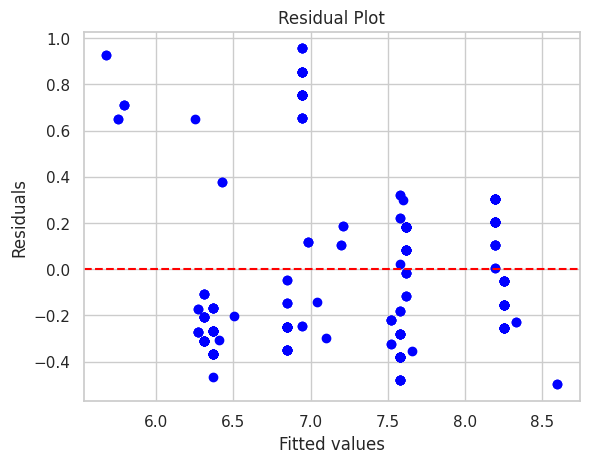

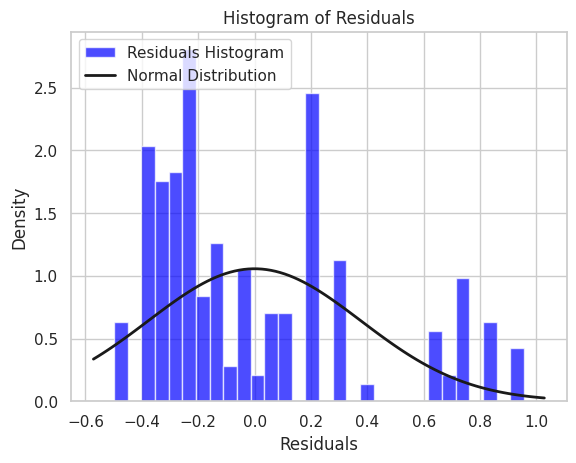

In [ ]:
pr.plot_res(SW)
pr.hist_res(SW)

Randomness: In this plot, residuals seem to be fairly scattered around the red horizontal line at zero. This suggests that there is no obvious non-linearity in the data, meaning that the linear model is somewhat appropriate.

Homoscedasticity (constant variance): The variance of residuals across the fitted values seems relatively constant (the spread doesn’t widen or narrow significantly across fitted values). This suggests that homoscedasticity is satisfied, meaning that the error variance is roughly equal across all levels of the predicted values.

Normality: The presence of distinct peaks (such as at 0.2 and -0.2) suggests some departure from a normal distribution, though the general shape of the residuals resembles a normal curve. In some cases, mild deviations from normality may not severely affect the validity of the model, especially for large sample sizes.




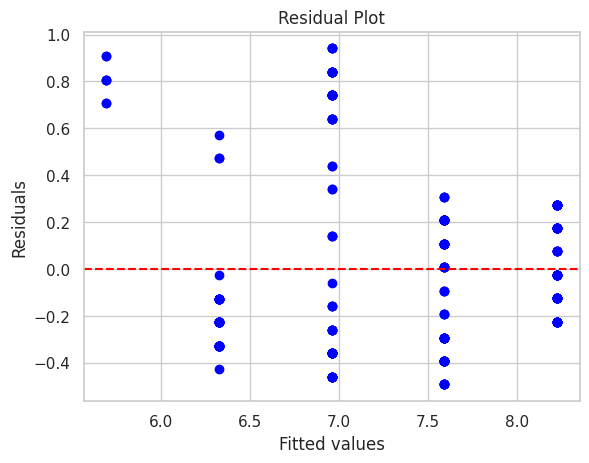

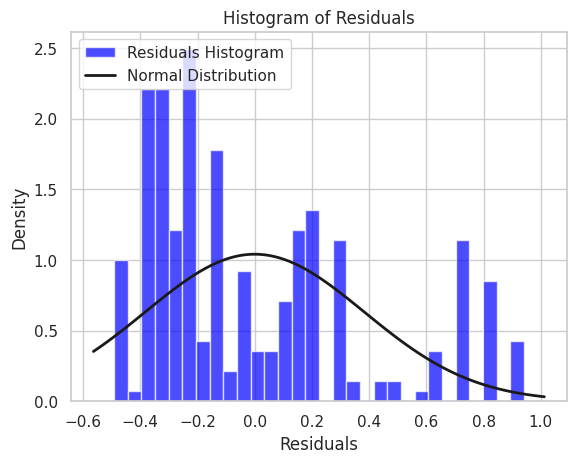

In [ ]:
pr.plot_res(reg)
pr.hist_res(reg)

The residual plots suggest that the assumptions of linearity and constant variance are reasonably satisfied, though there is some evidence of deviations from normality.